In [23]:
import pandas as pd
import numpy as np
from modAL.models import ActiveLearner
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras.optimizers import *
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Input, Activation, AveragePooling2D, Conv2DTranspose, ZeroPadding2D
from tensorflow.keras.layers import Dense , Dropout, Conv2D ,Flatten, Conv1D, BatchNormalization
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans

from matplotlib import pyplot as plt
import seaborn as sns
import copy
import math

font_size = 18

(array([-800., -600., -400., -200.,    0.,  200.,  400.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

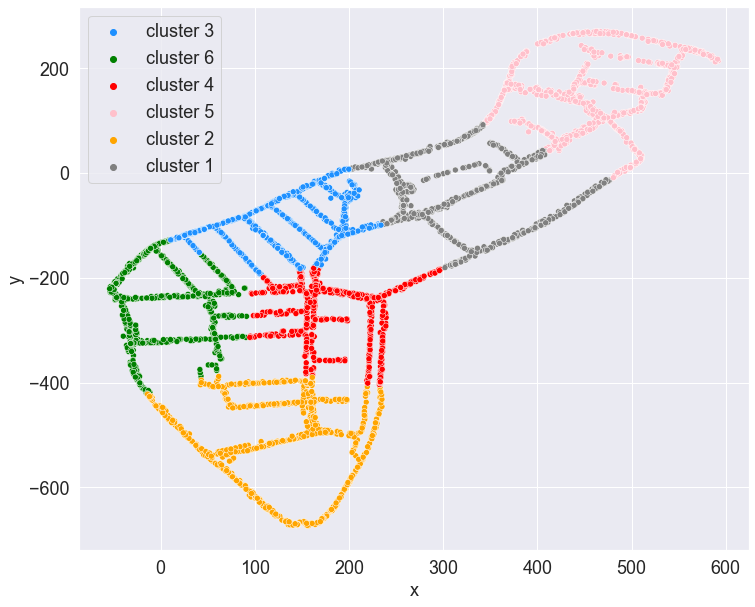

In [29]:
# load numpy raw data
with open('all_ae.npy', 'rb') as f:
    h2_ae = np.load(f)
    Pos = np.load(f)

h2_ae_shape = h2_ae.shape
h2_ae_1dcnn = h2_ae.reshape(h2_ae_shape[0], h2_ae_shape[1], -1)
h2_ae.shape, Pos.shape

# cluster the dataset for classification
pos_cluster = pd.DataFrame(Pos, columns=["x", "y", "z"])
kmeans = KMeans(n_clusters=6, random_state=42).fit(pos_cluster)
pos_cluster["cluster"] = kmeans.labels_
pos_cluster["cluster"] = pos_cluster["cluster"].replace({0: "cluster 1", 1: "cluster 2", 2: "cluster 3", 3: "cluster 4", 4: "cluster 5", 5: "cluster 6"})
pos_cluster["is_c1"] = 0
pos_cluster.loc[pos_cluster.cluster == "cluster 1", 'is_c1'] = 1
pos_cluster["is_c2"] = 0
pos_cluster.loc[pos_cluster.cluster == "cluster 2", 'is_c2'] = 1
pos_cluster["is_c3"] = 0
pos_cluster.loc[pos_cluster.cluster == "cluster 3", 'is_c3'] = 1
pos_cluster["is_c4"] = 0
pos_cluster.loc[pos_cluster.cluster == "cluster 4", 'is_c4'] = 1
pos_cluster["is_c5"] = 0
pos_cluster.loc[pos_cluster.cluster == "cluster 5", 'is_c5'] = 1
pos_cluster["is_c6"] = 0
pos_cluster.loc[pos_cluster.cluster == "cluster 6", 'is_c6'] = 1

sns.set()
plt.figure(figsize=(12, 10))
ax = sns.scatterplot(x="x", y="y", data=pos_cluster, hue="cluster", palette=["dodgerblue", "green", "red", "pink", "orange", "grey"])
plt.ylabel("y", fontsize=font_size)
plt.xlabel("x", fontsize=font_size)
plt.legend(prop={'size': font_size})
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)

In [6]:
result = 0
def distance(p1, p2):
    return np.linalg.norm(p1 - p2)

distance(pool_x_al[0], train_x_al[0])

20153.758

In [19]:
result = 0
for idx, x in enumerate(train_x_al):
    if train_y_al.iloc[idx]["cluster"] == pool_y_al.iloc[0]["cluster"]:
        result += distance(pool_x_al[0], x)
result

4603974.693359375

In [75]:
with open('dist_dict_pretrain2.npy', 'rb') as f:
    dist_dict_pretrain = np.load(f)
dist_dict_pretrain[30]

10415092.98046875

In [30]:
print("train-test splitting ae data...")
x_train_ae, x_test_ae, y_train_ae, y_test_ae = train_test_split(h2_ae, pos_cluster, test_size=0.1, random_state=42)
x_train_ae_cnn, x_test_ae_cnn, y_train, y_test = train_test_split(h2_ae_1dcnn, pos_cluster, test_size=0.1, random_state=42)

#y_train_ae_cnn = y_train[["x", "y", "z"]].values
y_test_ae_cnn = y_test[["x", "y", "z"]].values
print("splitting training data and active learning pool...")
train_x_al, pool_x_al, train_y_al, pool_y_al = train_test_split(x_train_ae_cnn, y_train, test_size=0.8, random_state=42)

y_train_cluster = y_train[["is_c1", "is_c2", "is_c3", "is_c4", "is_c5", "is_c6"]].values
y_test_cluster = y_test[["is_c1", "is_c2", "is_c3", "is_c4", "is_c5", "is_c6"]].values
train_x_cluster, pool_x_cluster, train_y_cluster, pool_y_cluster = train_test_split(x_train_ae_cnn, y_train_cluster, test_size=0.8, random_state=42)

train-test splitting ae data...
splitting training data and active learning pool...


In [35]:
t = np.where(pool_x_al[:,1]==pool_x_al[183])
t

/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/ipykernel_launcher.py:1: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  """Entry point for launching an IPython kernel.


(array([], dtype=int64),)

In [42]:
np.array_equal(pool_x_al[183], pool_x_al[183])

True

In [44]:
for idx,x in enumerate(pool_x_al):
    if np.array_equal(x, pool_x_al[183]):
        print(idx)

183


In [37]:
def get_prediction_precision(regressor, x_test, y_test):
    y_pred = regressor.predict(x_test)
    mse = mean_squared_error(y_true=y_test, y_pred=y_pred)
    #print(f"current MSE: {mse}")
    return mse

def cnn_model1(input_shape, opt=Adam(1e-3), dropout_rate=0.2):
    model = Sequential()
    model.add(Conv1D(16, 16, input_shape=input_shape, activation='relu'))
    model.add(Conv1D(32, 16, activation='relu'))
    model.add(Conv1D(32, 16, activation='relu'))
    model.add(Flatten())
    model.add(BatchNormalization())
    model.add(Dense(512))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dense(256))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(3))
    model.compile(loss='mean_squared_error', optimizer=opt)
    return model

# model for outputting probability
def cnn_model_clf(input_shape, opt=Adam(1e-3), dropout_rate=0.2):
    model = Sequential()
    model.add(Conv1D(16, 16, input_shape=input_shape, activation='relu'))
    model.add(Conv1D(32, 16, activation='relu'))
    model.add(Conv1D(32, 16, activation='relu'))
    model.add(Flatten())
    model.add(BatchNormalization())
    model.add(Dense(512))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dense(256))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(3, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model

print("constructing 1D-CNN models...")
lr = 5e-3
epochs = 50
decay_rate = lr / 50
model_ae = cnn_model1(train_x_al.shape[1:], opt=Adam(5e-3, decay=decay_rate))
model_clf = cnn_model_clf(train_x_cluster.shape[1:], opt=Adam(5e-3, decay=decay_rate))

constructing 1D-CNN models...


In [38]:
# 1. Fit on original training data
print(f"train_x_al:{train_x_al.shape}, train_y_al:{train_y_al.shape}")
model_ae.fit(train_x_al, train_y_al, epochs=1, validation_data=(
    x_test_ae_cnn, y_test_ae_cnn), verbose=1)
model_clf.fit(train_x_cluster, train_y_cluster, epochs=1, validation_data=(
    x_test_ae_cnn, y_test_cluster), verbose=1)
print(f"Initial round of training finished, MSE:{get_prediction_precision(model_ae, x_test_ae_cnn, y_test_ae_cnn)}")


train_x_al:(896, 56, 1184), train_y_al:(896, 3)
28/28 [==============================] - 2s 65ms/step - loss: 1.0959 - accuracy: 0.5257 - val_loss: 3.7513 - val_accuracy: 0.4659
Initial round of training finished, MSE:3766989.481863443


In [58]:
dist_dict = np.load('dist_dict.npy')

In [60]:
dist_dict.shape

(3585, 3585)

In [56]:
# dist_dict = []
# for i in range(len(pool_x_al)):
#     _row = []
#     for j in range(len(pool_x_al)):
#         _row.append(distance(pool_x_al[i], pool_x_al[j]))
#     dist_dict.append(_row)
# dist_dict = np.array(dist_dict)
# with open('dist_dict.npy', 'wb') as f:
#     np.save(f, dist_dict)
# print("dist_dict saved!")

In [64]:
def random_sampling(classifier, X_pool):
    n_samples = len(X_pool)
    query_idx = np.random.choice(range(n_samples))
    return [query_idx], X_pool[query_idx]

def distance(p1, p2):
    return np.linalg.norm(p1 - p2)

xs, ys = [], []
xs_idx = []
dist_dict = np.load('dist_dict.npy')
def location_based_sampling(classifier, X_pool):
    if len(X_pool) == 0:
        return random_sampling(classifier, X_pool)
    
    distances = [sum([dist_dict[chosen_idx][cur_idx] for chosen_idx in xs_idx]) for cur_idx, x in enumerate(X_pool)]
    query_idx = distances.index(max(distances))
    return [query_idx], X_pool[query_idx]

def location_based_sampling2(classifier, X_pool):
    overall_distances = [sum([dist_dict[_chosen_idx][cur_idx] for _chosen_idx in xs_idx]) + dist_dict_pretrain[cur_idx] for cur_idx, x in enumerate(X_pool)]
    overall_distances_np = np.array(overall_distances)
    maxes = classifier.predict_proba(X_pool).max(axis=1)
    uncertainties = np.full(len(overall_distances), 1) - maxes
    product = overall_distances_np * uncertainties
    query_idx = list(product).index(max(product))
    return query_idx, X_pool[query_idx]

In [43]:
dist_dict_pretrain = list(np.load('dist_dict_pretrain.npy'))
dist_dict_pretrain.index(max(dist_dict_pretrain))

2036

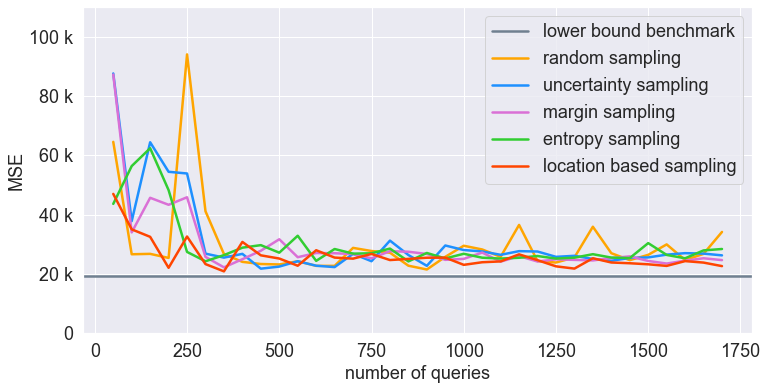

In [53]:
# after bootstrap
# mse_dict_uncertainty_all = {50: 65274.10617262323, 100: 47983.413478226925, 150: 26983.203641819764, 200: 23294.31099955719, 250: 25767.44701760128, 300: 31415.140141454478, 350: 31105.991843989013, 400: 27092.073001079134, 450: 35079.79240952116, 500: 24737.2838222193, 550: 23151.96876497875, 600: 24261.26749647967, 650: 24512.062144447933, 700: 24604.692696459675, 750: 24176.277237716175, 800: 26059.26547327766, 850: 27632.748908348494, 900: 23435.436915971364, 950: 23772.73363501368, 1000: 22879.49065328263, 1050: 22032.062414307245, 1100: 23282.969981022256, 1150: 24243.42911624546, 1200: 23321.90422994128, 1250: 21807.755052372228, 1300: 25105.341141332796, 1350: 26304.221968649636, 1400: 24385.826748441923, 1450: 23298.717850202564, 1500: 23529.185271881477, 1550: 23792.64497272381, 1600: 22563.45969709588, 1650: 23508.140939580797, 1700: 25171.42693264304}
# mse_dict_random_all = {50: 43938.65473272116, 100: 45414.48644163506, 150: 32936.1708191538, 200: 28020.95655935872, 250: 46733.35922744398, 300: 34855.51274405723, 350: 25121.05109737441, 400: 26326.092118955086, 450: 25623.495805314145, 500: 26046.956065929753, 550: 23262.249193148164, 600: 26053.763465327404, 650: 29358.360986277115, 700: 23846.1502608646, 750: 28413.213935541935, 800: 28401.46385156857, 850: 23584.242291479484, 900: 28901.89881011218, 950: 23808.375253824895, 1000: 22714.573657607438, 1050: 24120.740246977162, 1100: 26703.728214707702, 1150: 24717.33998396136, 1200: 42419.127575922765, 1250: 25372.907570312494, 1300: 34131.830719717196, 1350: 25395.34618173241, 1400: 26233.997076685435, 1450: 24542.40961228075, 1500: 23536.65718857488, 1550: 25567.64369904011, 1600: 26314.55865681308, 1650: 23815.499750545205, 1700: 24171.411069551297}

# mse_dict_margin_all = {50: 51284.7889639079, 100: 66016.85194045343, 150: 30273.315947502284, 200: 30510.82017951523, 250: 101819.90187829953, 300: 38640.28536421815, 350: 61023.50973416321, 400: 39791.17053809991, 450: 33765.272898954434, 500: 25399.624299885418, 550: 25295.027473948994, 600: 29622.44115548955, 650: 22079.748127691277, 700: 26585.907866276033, 750: 23744.630069383275, 800: 33232.0238208386, 850: 22102.53742151872, 900: 22752.360947639696, 950: 24208.144510679806, 1000: 21562.274649640396, 1050: 26998.73762918318, 1100: 24560.675992117074, 1150: 22452.813376793336, 1200: 23929.085556499747, 1250: 21515.396521110073, 1300: 21002.850865800327, 1350: 20719.38535556257, 1400: 22377.759285214455, 1450: 21627.643168845763, 1500: 22310.4018052671, 1550: 22741.272950609113, 1600: 21881.32329409153, 1650: 27603.12559227485, 1700: 24481.910818201824}
# mse_dict_entropy_all = {50: 28380.728995871905, 100: 25999.777289061687, 150: 22867.76505331373, 200: 28199.529204771632, 250: 25441.47017795502, 300: 25003.850975922735, 350: 23999.76663088189, 400: 23389.13185333071, 450: 28617.153615144096, 500: 21572.535891404164, 550: 23780.802876654794, 600: 27012.64679644414, 650: 24011.72121292667, 700: 38444.200770061805, 750: 22689.47333404826, 800: 25654.592084456395, 850: 28205.596121859, 900: 25440.040743286863, 950: 25117.27085514094, 1000: 23442.317186662574, 1050: 23036.608919064194, 1100: 23096.5961593425, 1150: 23124.530170379745, 1200: 24805.102946529525, 1250: 25953.39294655282, 1300: 23577.54266208186, 1350: 25200.517051388724, 1400: 24119.660713122023, 1450: 25046.87818086985, 1500: 23816.1011390917, 1550: 24551.050842369663, 1600: 21517.733642173673, 1650: 24585.92453574138, 1700: 24052.50585216122}

mse_dict_margin_all = {50: 87274.2314127471, 100: 34021.824370248396, 150: 45700.84007427305, 200: 43340.065112824326, 250: 45879.24136591033, 300: 25766.13681655633, 350: 22241.963323763815, 400: 24985.449233506533, 450: 27837.902616235748, 500: 31716.301588563274, 550: 25663.238247685007, 600: 27076.298476021922, 650: 26998.717610840406, 700: 26737.168140556667, 750: 25289.05601126204, 800: 27697.33896683258, 850: 27504.65358577123, 900: 26754.989114975222, 950: 24773.299088648564, 1000: 25101.928522939106, 1050: 27227.69399556109, 1100: 24164.550928108918, 1150: 26037.225874089945, 1200: 24209.413818716403, 1250: 24950.717669951347, 1300: 24763.408208758545, 1350: 24578.07583715835, 1400: 25380.003846957366, 1450: 25934.12376198894, 1500: 24399.600458797115, 1550: 23522.946025523994, 1600: 24495.582357090203, 1650: 25304.34901091985, 1700: 24687.799941881807}

mse_dict_entropy_all = {50: 43650.01194239468, 100: 56401.77449741168, 150: 62413.26626018912, 200: 48288.10312340775, 250: 27443.105024640085, 300: 24290.64510205304, 350: 26368.529177286186, 400: 28878.98117016643, 450: 29732.291006685406, 500: 27190.734194091376, 550: 32905.46012192293, 600: 24426.388992398133, 650: 28430.408423583347, 700: 26864.883394596593, 750: 26987.97185065731, 800: 28571.15357147974, 850: 24247.303813832255, 900: 27091.97588363064, 950: 25245.2212014816, 1000: 26816.530418145732, 1050: 25497.861921055548, 1100: 25210.55472045959, 1150: 25480.490149725912, 1200: 26060.992616962176, 1250: 25205.746098749394, 1300: 25508.081123618962, 1350: 26678.33586806679, 1400: 25537.866295729134, 1450: 25371.75630075664, 1500: 30412.57020292715, 1550: 26435.162623301014, 1600: 25294.681106169268, 1650: 27953.333995516823, 1700: 28434.0159512633}

mse_dict_uncertainty_all = {50: 87629.04252421782, 100: 37832.80640381217, 150: 64430.23905767614, 200: 54470.909364640305, 250: 53897.79987059656, 300: 26868.704152983923, 350: 25527.601566367444, 400: 26788.647703442894, 450: 21799.59864454196, 500: 22501.180930248476, 550: 24300.086692563225, 600: 22793.96013749774, 650: 22327.322885575613, 700: 26804.454509330404, 750: 24307.578869441888, 800: 31259.330054888076, 850: 26402.17077145626, 900: 22754.42979547521, 950: 29612.911640898343, 1000: 28083.84035950064, 1050: 27604.907585675417, 1100: 26468.33116475996, 1150: 27706.93369375773, 1200: 27579.479499608013, 1250: 25784.321183644453, 1300: 26135.702640990898, 1350: 25078.52616574628, 1400: 24468.77576536007, 1450: 25407.116028916487, 1500: 25593.70828006933, 1550: 26523.03347655087, 1600: 27029.879742834102, 1650: 26881.291398721576, 1700: 26285.65118480298}

mse_dict_random_all = {50: 64560.27488355944, 100: 26656.320165685156, 150: 26791.743413117598, 200: 25417.141337022404, 250: 94060.02358323918, 300: 41158.38147195243, 350: 26735.45601822592, 400: 24095.09298239557, 450: 23364.14391864023, 500: 23220.05182452103, 550: 24297.446131139262, 600: 22750.111461659286, 650: 22743.269487215905, 700: 28806.65352557978, 750: 27748.564063692134, 800: 27188.77247402727, 850: 22796.744506706706, 900: 21519.772259155838, 950: 25790.632232691318, 1000: 29526.095728379583, 1050: 28274.788905171503, 1100: 25789.39064974111, 1150: 36552.09862573303, 1200: 24359.899872777245, 1250: 23869.967001947094, 1300: 25586.31542786026, 1350: 35938.94001549325, 1400: 27013.95412427641, 1450: 24671.70363909544, 1500: 26455.032982821893, 1550: 29978.299390030545, 1600: 24718.025123760588, 1650: 26787.88301615208, 1700: 34183.66282587346}


#mse_dict_lb_all = {50: 63793.35322866152, 100: 32665.356391725833, 150: 34213.24419108607, 200: 26765.756906961014, 250: 25376.85146811727, 300: 28418.046579956677, 350: 29304.314415479155, 400: 26617.188472220285, 450: 21986.99545489457, 500: 27044.578759677042, 550: 26015.64067332863, 600: 26112.666300902518, 650: 26878.31881444877, 700: 23572.085488308778, 750: 23129.61983193779, 800: 23972.044759768425, 850: 25618.858473716307, 900: 24282.93427938715, 950: 24407.91556466366, 1000: 26548.71274406271, 1050: 25551.41504941434, 1100: 23520.8412533955, 1150: 24691.729223783375, 1200: 24615.35257332175, 1250: 23756.42507398524, 1300: 24189.57145174289, 1350: 24794.736088634283, 1400: 25414.917041573077, 1450: 25354.127418572298, 1500: 24223.09591946796, 1550: 23802.236780412073, 1600: 24847.60547115233, 1650: 25630.959525050504, 1700: 25096.959217328127}
mse_dict_lb_all = {50: 47013.36124811063, 100: 35057.558445162875, 150: 32534.898489731975, 200: 22088.30340771105, 250: 32641.578826262004, 300: 23338.245118097326, 350: 20888.697164389116, 400: 30818.297516016395, 450: 26295.11618678235, 500: 25212.72551054585, 550: 22787.664741761357, 600: 28014.17832842826, 650: 25533.874190203802, 700: 25177.676201756476, 750: 26766.092692727918, 800: 24703.966467336923, 850: 25094.094196336813, 900: 25489.40307126591, 950: 25522.02753205675, 1000: 23087.677003250807, 1050: 23964.828877446358, 1100: 24246.837782810424, 1150: 26628.652798621686, 1200: 24662.386306121636, 1250: 22584.037806740667, 1300: 21819.10637584992, 1350: 25312.030759024885, 1400: 23880.62392423955, 1450: 23625.12585537409, 1500: 23270.183095545075, 1550: 22729.779388992716, 1600: 24346.776392657168, 1650: 23845.91585883473, 1700: 22659.42065609706}


n_queries = list(mse_dict_uncertainty_all.keys())
mses_random_all = list(mse_dict_random_all.values())
mses_uncertainty_all = list(mse_dict_uncertainty_all.values())
mses_margin_all = list(mse_dict_margin_all.values())
mses_entropy_all = list(mse_dict_entropy_all.values())
mses_lb_all = list(mse_dict_lb_all.values())[:len(n_queries)]


font_size = 18
line_width = 2.5
import matplotlib.ticker as ticker
sns.set()
fig, ax = plt.subplots(figsize=(12, 6))
#plt.figure(figsize=(12, 6))
y_bm = 19258.3560

plt.axhline(y=y_bm, color='slategray', linestyle='-', label="lower bound benchmark", linewidth=line_width)
plt.plot(n_queries, mses_random_all, label="random sampling", linewidth=line_width, color="orange")
plt.plot(n_queries, mses_uncertainty_all, label="uncertainty sampling", linewidth=line_width, color="dodgerblue")
plt.plot(n_queries, mses_margin_all, label="margin sampling", linewidth=line_width, color="orchid")
plt.plot(n_queries, mses_entropy_all, label="entropy sampling", linewidth=line_width, color="limegreen")
plt.plot(n_queries, mses_lb_all, label="location based sampling", linewidth=line_width, color="orangered")


plt.ylabel("MSE", fontsize=font_size)
plt.xlabel("number of queries", fontsize=font_size)
plt.legend(prop={'size': font_size})
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)

plt.ylim((0, 110000))
ax.yaxis.set_major_formatter(ticker.EngFormatter())

Text(0.5, 0, 'MSE')

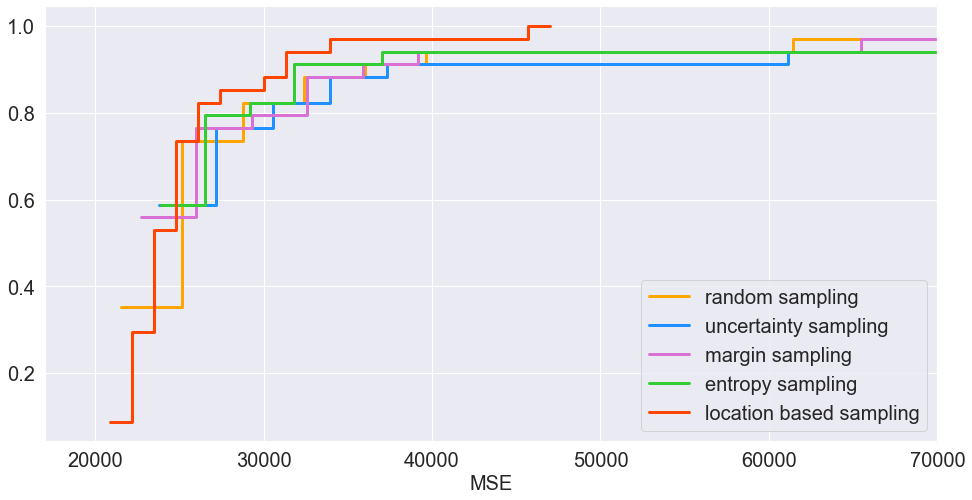

In [25]:
fig, ax = plt.subplots(figsize=(16, 8))
font_size = 20
line_width = 3
colors = {
    "uncertainty": "dodgerblue",
    "margin": "orchid",
    "entropy": "limegreen",
    "random": "orange",
    "location based": "orangered",
    "full": "slategray"
}
def plot_qs_cdf(qs_name, qs_var):
    counts, bins = np.histogram(qs_var, bins=20)
    cdf = np.cumsum(counts)/np.sum(counts)

    plt.plot(
        np.vstack((bins, np.roll(bins, -1))).T.flatten()[:-2],
        np.vstack((cdf, cdf)).T.flatten(), label=f"{qs_name} sampling",
        linewidth=line_width,
        color=colors[qs_name]
    )

plot_qs_cdf("random", mses_random_all)
plot_qs_cdf("uncertainty", mses_uncertainty_all)
plot_qs_cdf("margin", mses_margin_all)
plot_qs_cdf("entropy", mses_entropy_all)
plot_qs_cdf("location based", mses_lb_all)

plt.xlim(17000, 70000)
plt.legend(loc="lower right", prop={'size': font_size})
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)
plt.xlabel("MSE", fontsize=font_size)

(-700.0, 350.0)

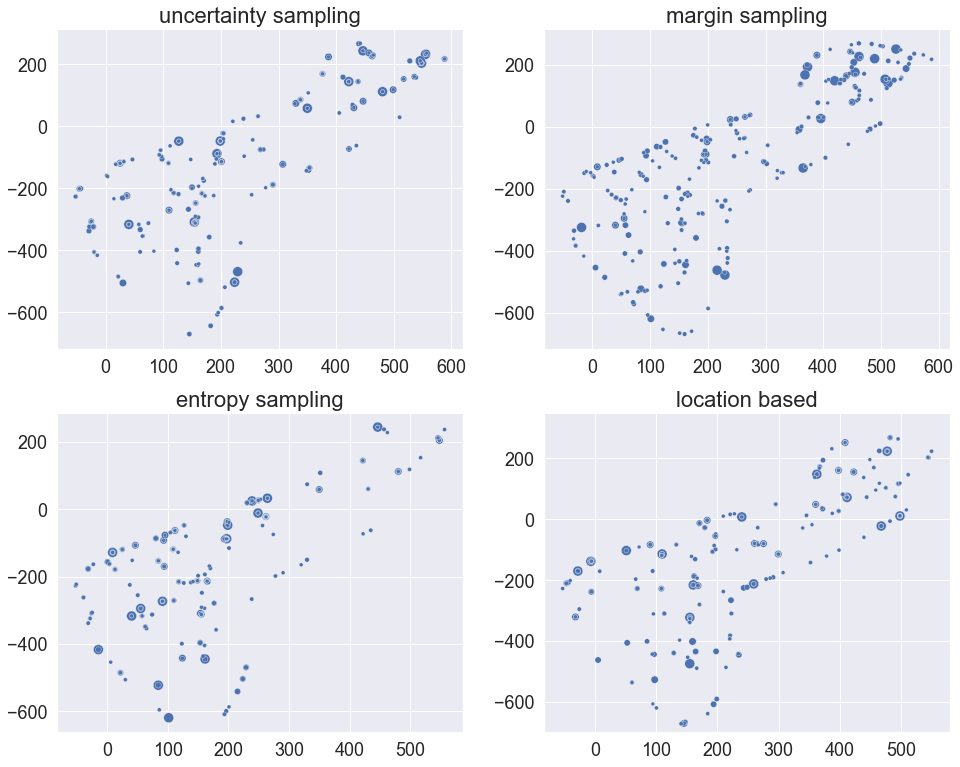

In [48]:
# Looking at the chosen samples by the 4 uncertainty sampling methods
plt.subplots(2, 2, figsize=(16, 20))
font_size = 18
fs_title = 22

def plot_qs_chosen(qs_name, idx, fullname=None):
    if fullname is not None:
        filename = f"chosen/{fullname}.csv"
    else:
        filename = f"chosen/cnn_ae_al2_{qs_name}_all_chosen_250iter_5cluster.csv"
    df_chosen = pd.read_csv(filename, index_col=0)
    df_chosen["iter"] = df_chosen["iter"] + 1
    batch = 15
    df_chosen["size"] = df_chosen["iter"].apply(lambda val: 5 / (((val - (val % batch)) / batch) + 1))
    sns.set()
    if fullname is None:
        plt.subplot(3, 2, idx)
    ax = sns.scatterplot(x="x", y="y", data=df_chosen, size="size", sizes=(15, 100))
    plt.title(f"{qs_name} sampling", fontsize=fs_title)
    plt.xticks(fontsize=font_size)
    plt.yticks(fontsize=font_size)
    plt.xlabel("MSE", fontsize=font_size)
    ax.xaxis.label.set_visible(False)
    ax.yaxis.label.set_visible(False)
    ax.get_legend().remove()

#plot_qs_chosen("random", 1)
plot_qs_chosen("uncertainty", 1)
plot_qs_chosen("margin", 2)
plot_qs_chosen("entropy", 3)
plot_qs_chosen("lb2", 4)
plt.title("location based", fontsize=fs_title)
plt.ylim(-700, 350)

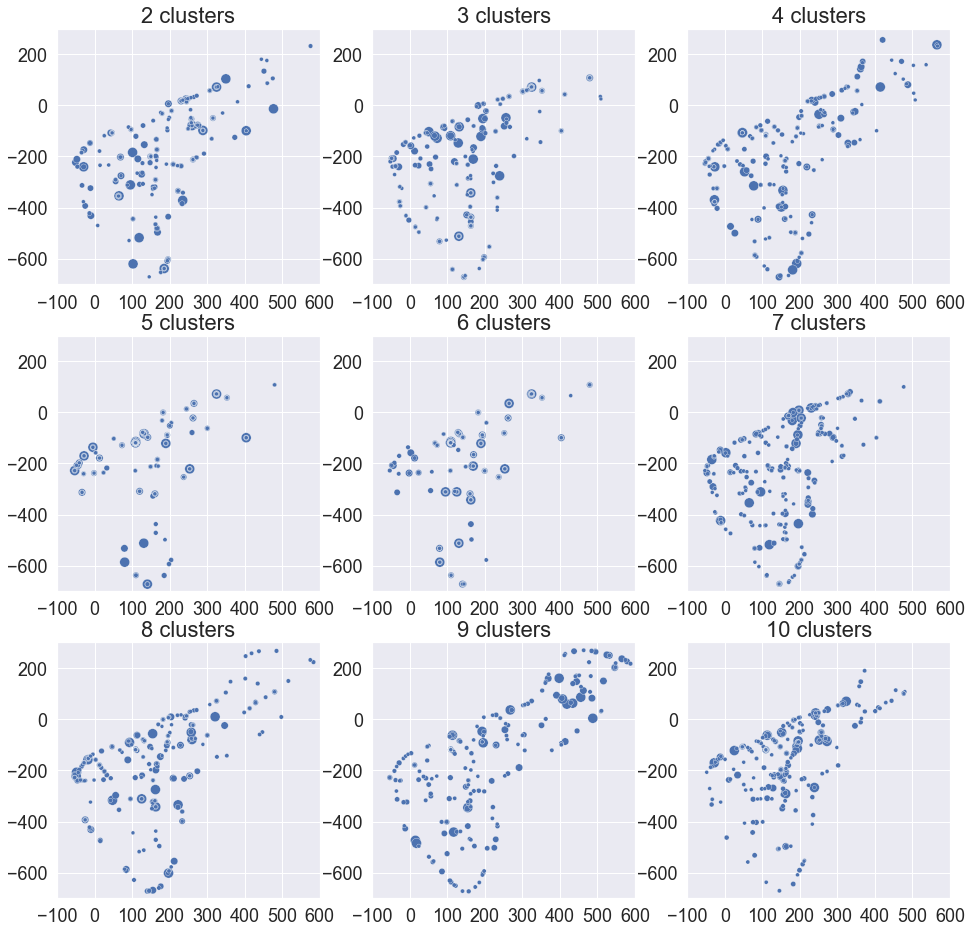

In [11]:
plt.subplots(3, 3, figsize=(16, 16))
for i in range(2, 11):
    plt.subplot(3, 3, i - 1)
    plot_qs_chosen("lb2", 1, f"cnn_ae_al2_lb2_all_chosen_250iter_{i}cluster")
    plt.title(f"{i} clusters", fontsize=fs_title)
    plt.xlim(-100, 600)
    plt.ylim(-700, 300)

(-100.0, 700.0)

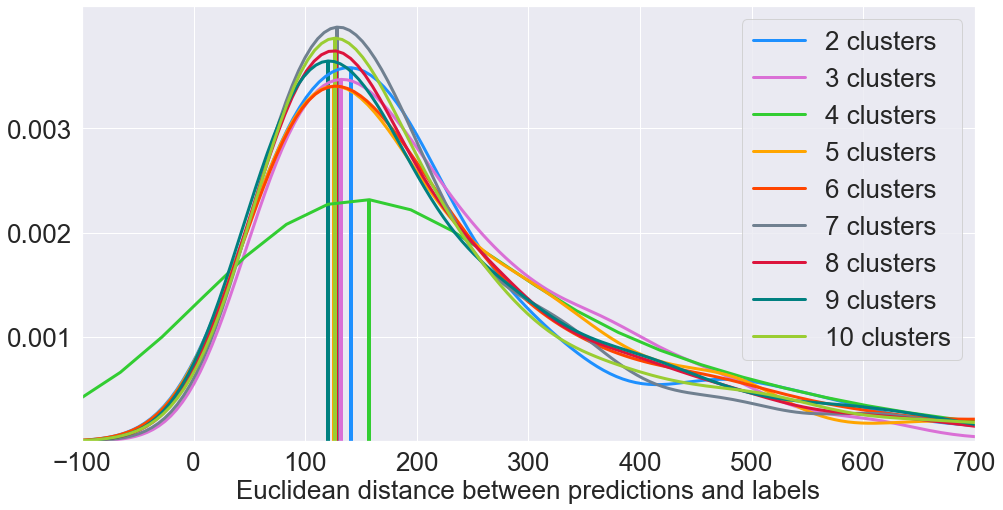

In [21]:
colors = {
    "2": "dodgerblue",
    "3": "orchid",
    "4": "limegreen",
    "5": "orange",
    "6": "orangered",
    "7": "slategray",
    "8": "crimson",
    "9": "teal",
    "10": "yellowgreen"
}
line_width = 3
v_line_width = 4
font_size = 26
sns.set()

def euclidean(x_diff, y_diff, z_diff):
    return math.sqrt(x_diff**2 + y_diff**2 + z_diff**2)

def plot_diff_kde_xyz2(filename, label, line_idx):
    preds = pd.read_csv(f"preds/{filename}")
    preds = preds[["x", "y", "z"]]
    preds["type"] = "pred"
    truth = pd.DataFrame(y_test_ae_cnn, columns=["x", "y", "z"])
    truth = truth[["x", "y", "z"]]
    truth["type"] = "truth"
    concat = pd.concat([preds, truth], axis=1, ignore_index=True)
    concat.columns = ["x_p", "y_p", "z_p", "t1", "x_t", "y_t", "z_t", "t2"]
    concat["x_diff"] = abs(concat["x_p"] - concat["x_t"])
    concat["y_diff"] = abs(concat["y_p"] - concat["y_t"])
    concat["z_diff"] = abs(concat["z_p"] - concat["z_t"])
    concat["eucl"] = concat.apply(lambda row: euclidean(row["x_diff"], row["y_diff"], row["z_diff"]), axis=1)
    
    p = sns.kdeplot(concat[f"eucl"], label=label + " clusters", color=colors[label], linewidth=line_width)
    x, y = p.get_lines()[line_idx].get_data()
    y_argmax = np.argmax(y)
    x_curt = x[y_argmax]
    plt.vlines(x_curt, 0, max(y), color=colors[label], linewidth=v_line_width)
    plt.legend()
    plt.ylabel("")
    plt.xlabel(f"Euclidean distance between predictions and labels", fontsize=font_size)
    plt.legend(prop={'size': font_size})
    plt.xticks(fontsize=font_size)
    plt.yticks([0.001, 0.002, 0.003], fontsize=font_size)

plt.figure(figsize=(16, 8))
plot_diff_kde_xyz2("cnn_ae_al2_lb2_650_2cluster.csv", "2", 0)
plot_diff_kde_xyz2("cnn_ae_al2_lb2_650_3cluster.csv", "3", 1)
plot_diff_kde_xyz2("cnn_ae_al2_lb2_650_4cluster.csv", "4", 2)
plot_diff_kde_xyz2("cnn_ae_al2_lb2_650_5cluster.csv", "5", 3)
plot_diff_kde_xyz2("cnn_ae_al2_lb2_650_6cluster.csv", "6", 4)
plot_diff_kde_xyz2("cnn_ae_al2_lb2_650_7cluster.csv", "7", 5)
plot_diff_kde_xyz2("cnn_ae_al2_lb2_650_8cluster.csv", "8", 6)
plot_diff_kde_xyz2("cnn_ae_al2_lb2_650_9cluster.csv", "9", 7)
plot_diff_kde_xyz2("cnn_ae_al2_lb2_650_10cluster.csv", "10", 8)

plt.xlim(-100, 700)

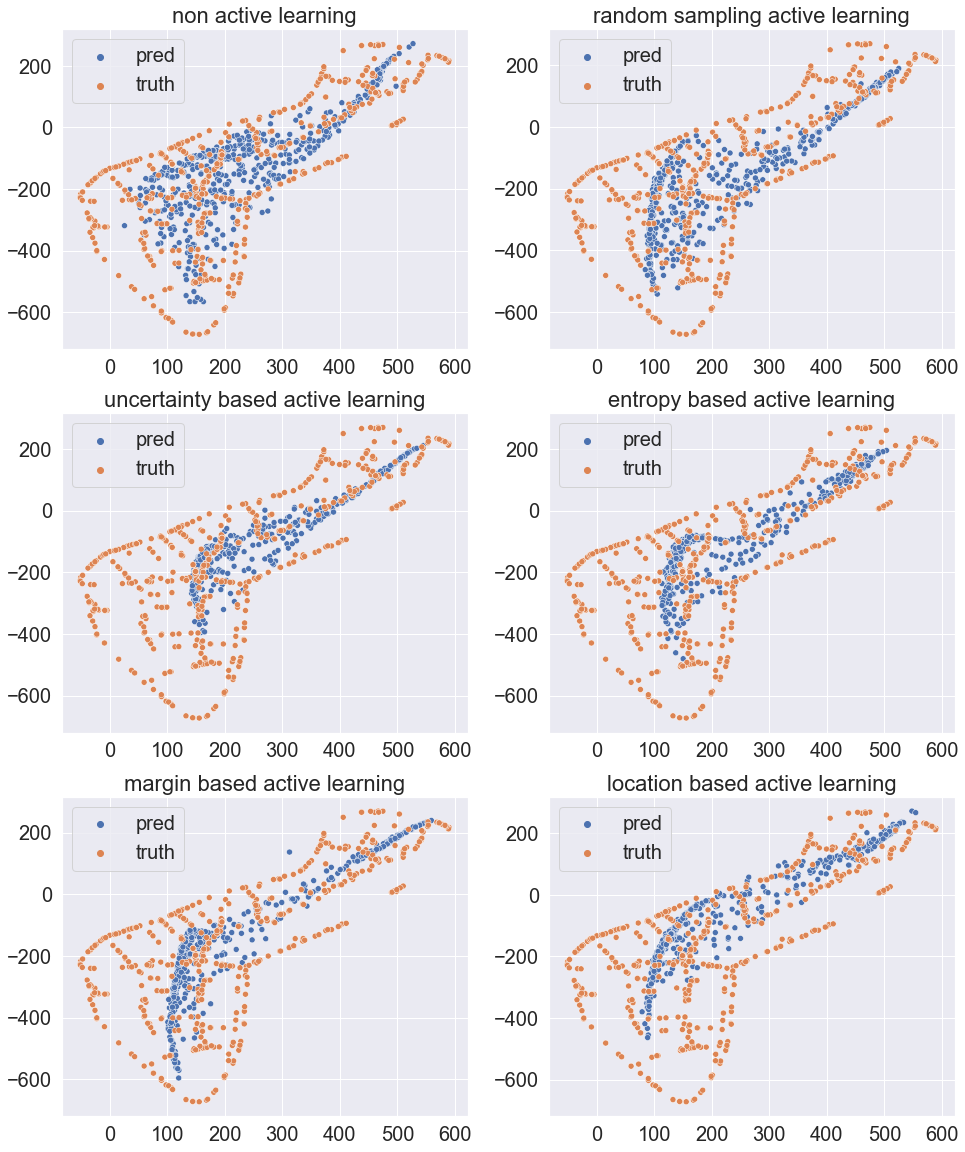

In [19]:
font_size = 20
fs_title = 22
def _plot_qs_comp(y_test, filename, title):
    file = f"{filename}.csv"
    preds = pd.read_csv(f"preds/{file}")
    preds = preds[["x", "y", "z"]]
    preds["type"] = "pred"
    truth = pd.DataFrame(y_test, columns=["x", "y", "z"])
    truth["type"] = "truth"
    concat = pd.concat([preds, truth], ignore_index=True)
    concat = concat[concat["x"]<600]
    ax = sns.scatterplot(x="x", y="y", data=concat, hue="type")
#     plt.ylabel("y", fontsize=font_size)
#     plt.xlabel("x", fontsize=font_size)
    ax.xaxis.label.set_visible(False)
    ax.yaxis.label.set_visible(False)
    plt.legend(prop={'size': font_size})
    plt.xticks(fontsize=font_size)
    plt.yticks(fontsize=font_size)
    ax.set_title(title, fontsize=fs_title)

def compare_predictions(y_test, x_test=None, model=None):
    plt.subplots(3, 2, figsize=(16, 20))
    plt.subplot(3, 2, 1)
    _plot_qs_comp(y_test, "cnn_ae_full_all_preds", "non active learning")
    
    plt.subplot(3, 2, 2)
    _plot_qs_comp(y_test, "cnn_ae_al2_random_800", "random sampling active learning")

    plt.subplot(3, 2, 3)
    _plot_qs_comp(y_test, "cnn_ae_al2_uncertainty_800", "uncertainty based active learning")
    
    plt.subplot(3, 2, 4)
    _plot_qs_comp(y_test, "cnn_ae_al2_entropy_800", "entropy based active learning")
    
    plt.subplot(3, 2, 5)
    _plot_qs_comp(y_test, "cnn_ae_al2_margin_800", "margin based active learning")
    
    plt.subplot(3, 2, 6)
    _plot_qs_comp(y_test, "cnn_ae_al2_lb2_800", "location based active learning")
    
    
compare_predictions(y_test_ae)

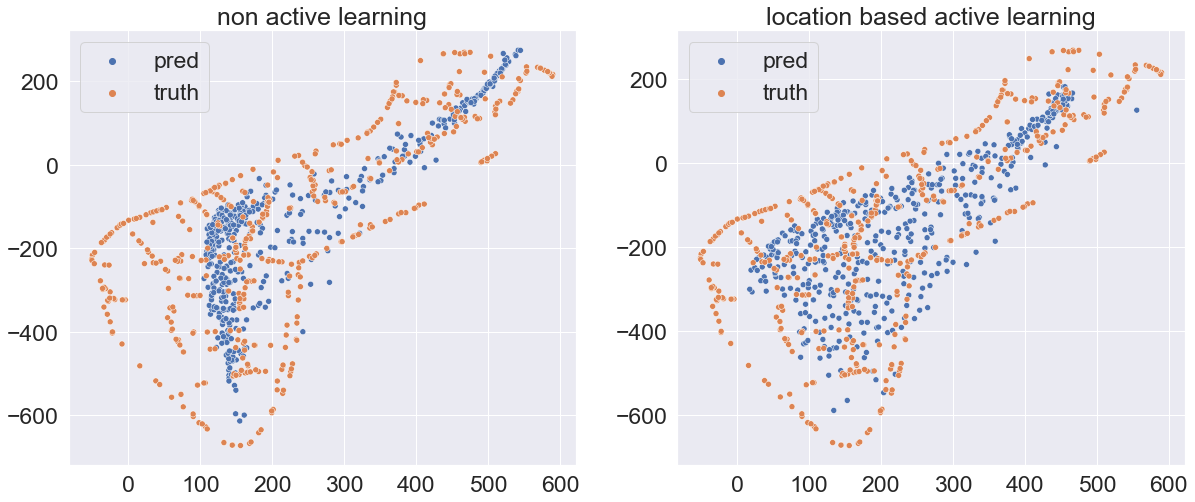

In [97]:
def _plot_qs_comp(y_test, filename, title):
    file = f"{filename}.csv"
    preds = pd.read_csv(f"preds/{file}")
    preds = preds[["x", "y", "z"]]
    preds["type"] = "pred"
    truth = pd.DataFrame(y_test, columns=["x", "y", "z"])
    truth["type"] = "truth"
    concat = pd.concat([preds, truth], ignore_index=True)
    concat = concat[concat["x"]<600]
    ax = sns.scatterplot(x="x", y="y", data=concat, hue="type")
#     plt.ylabel("y", fontsize=font_size)
#     plt.xlabel("x", fontsize=font_size)
    ax.xaxis.label.set_visible(False)
    ax.yaxis.label.set_visible(False)
    plt.legend(prop={'size': font_size})
    plt.xticks(fontsize=font_size)
    plt.yticks(fontsize=font_size)
    ax.set_title(title, fontsize=fs_title)

font_size = 23
fs_title = 25
plt.subplots(1, 2, figsize=(20, 8))
plt.subplot(1, 2, 1)
_plot_qs_comp(y_test, "cnn_ae_full_all_preds_23iter", "non active learning")
plt.subplot(1, 2, 2)
_plot_qs_comp(y_test, "cnn_ae_al3_lb2_all_preds", "location based active learning")


(-100.0, 700.0)

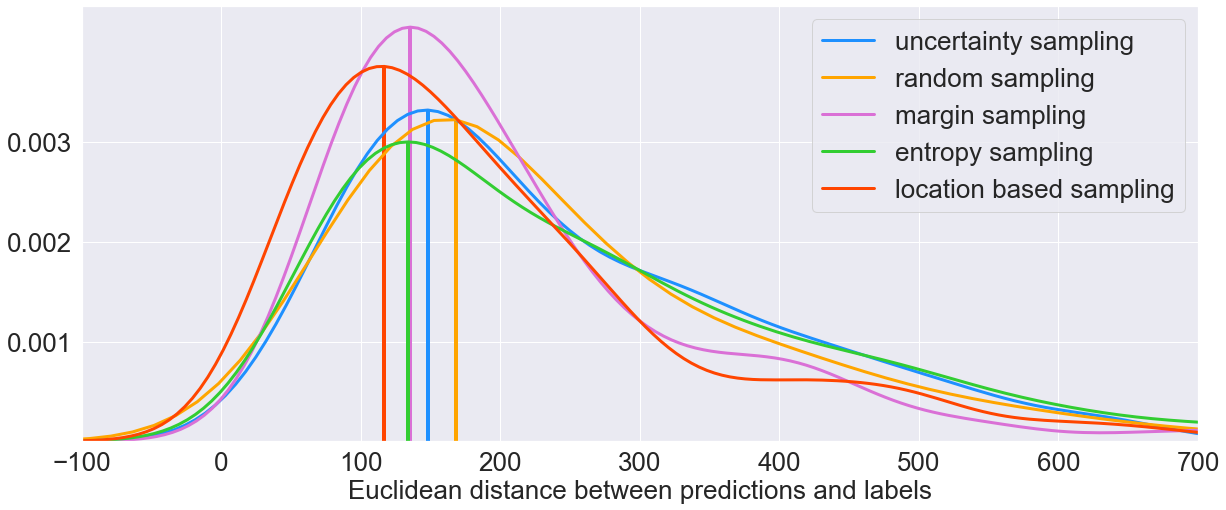

In [19]:
#fig, axes = plt.subplots(3, 1, figsize=(16, 11))
colors = {
    "uncertainty": "dodgerblue",
    "margin": "orchid",
    "entropy": "limegreen",
    "random": "orange",
    "location based": "orangered",
    "full": "slategray"
}
line_width = 3
v_line_width = 4
font_size = 26
sns.set()

def plot_diff_kde(filename, label, line_idx, axis="x"):
    preds = pd.read_csv(f"preds/{filename}")
    preds = preds[["x", "y", "z"]]
    preds["type"] = "pred"
    truth = pd.DataFrame(y_test_ae_cnn, columns=["x", "y", "z"])
    truth = truth[["x", "y", "z"]]
    truth["type"] = "truth"
    concat = pd.concat([preds, truth], axis=1, ignore_index=True)
    concat.columns = ["x_p", "y_p", "z_p", "t1", "x_t", "y_t", "z_t", "t2"]
    concat[f"{axis}_diff"] = abs(concat[f"{axis}_p"] - concat[f"{axis}_t"])
    p = sns.kdeplot(concat[f"{axis}_diff"], label=label, color=colors[label], linewidth=line_width)
    x, y = p.get_lines()[line_idx].get_data()
    y_argmax = np.argmax(y)
    x_curt = (x[y_argmax] + x[y_argmax + 1]) / 2
    
    plt.vlines(x_curt, 0, y[y_argmax], color=colors[label], linewidth=v_line_width)
    if axis == "x":
        plt.xlim(-60, 400)
        plt.xticks(np.arange(-50, 450, 50))
        plt.yticks([0, 0.002, 0.004, 0.006])
    elif axis == "y":
        plt.xlim(-100, 600)
        plt.xticks(np.arange(-100, 650, 50))
        plt.yticks([0, 0.001, 0.002, 0.003, 0.004])
    elif axis == "z":
        plt.xticks(np.arange(-10, 70, 10))
        plt.xlim(-10, 60)
    plt.legend()
    plt.ylabel("")
    plt.xlabel(f"diff in {axis} axis", fontsize=font_size)
    plt.legend(prop={'size': font_size})
    plt.xticks(fontsize=font_size)
    plt.yticks(fontsize=font_size)
    
def euclidean(x_diff, y_diff, z_diff):
    return math.sqrt(x_diff**2 + y_diff**2 + z_diff**2)
    
def plot_diff_kde_xyz(filename, label, line_idx):
    preds = pd.read_csv(f"preds/{filename}")
    preds = preds[["x", "y", "z"]]
    preds["type"] = "pred"
    truth = pd.DataFrame(y_test_ae_cnn, columns=["x", "y", "z"])
    truth = truth[["x", "y", "z"]]
    truth["type"] = "truth"
    concat = pd.concat([preds, truth], axis=1, ignore_index=True)
    concat.columns = ["x_p", "y_p", "z_p", "t1", "x_t", "y_t", "z_t", "t2"]
    concat["x_diff"] = abs(concat["x_p"] - concat["x_t"])
    concat["y_diff"] = abs(concat["y_p"] - concat["y_t"])
    concat["z_diff"] = abs(concat["z_p"] - concat["z_t"])
    concat["eucl"] = concat.apply(lambda row: euclidean(row["x_diff"], row["y_diff"], row["z_diff"]), axis=1)
    
    p = sns.kdeplot(concat[f"eucl"], label=label + " sampling", color=colors[label], linewidth=line_width)
    x, y = p.get_lines()[line_idx].get_data()
    y_argmax = np.argmax(y)
    x_curt = x[y_argmax]
    plt.vlines(x_curt, 0, max(y), color=colors[label], linewidth=v_line_width)
    plt.legend()
    plt.ylabel("")
    plt.xlabel(f"Euclidean distance between predictions and labels", fontsize=font_size)
    plt.legend(prop={'size': font_size})
    plt.xticks(fontsize=font_size)
    plt.yticks([0.001, 0.002, 0.003], fontsize=font_size)
    
fig, axes = plt.subplots(figsize=(20, 8))
plot_diff_kde_xyz("cnn_ae_al2_uncertainty_650.csv", "uncertainty", 0)
plot_diff_kde_xyz("cnn_ae_al2_random_650.csv", "random", 1)
plot_diff_kde_xyz("cnn_ae_al2_margin_650.csv", "margin", 2)
plot_diff_kde_xyz("cnn_ae_al2_entropy_650.csv", "entropy", 3)
plot_diff_kde_xyz("cnn_ae_al2_lb2_650.csv", "location based", 4)
plt.xlim(-100, 700)

# plt.subplot(3, 1, 1)
# plot_diff_kde("cnn_ae_al2_uncertainty_all_preds.csv", "uncertainty", 0, "x")
# plot_diff_kde("cnn_ae_al1_random_all_preds.csv", "random", 1, "x")
# plot_diff_kde("cnn_ae_al2_entropy_all_preds.csv", "entropy", 2, "x")
# plot_diff_kde("cnn_ae_al2_margin_all_preds.csv", "margin", 3, "x")
# plot_diff_kde("cnn_ae_al1_lb_all_preds.csv", "location based", 4, "x")

# plt.subplot(3, 1, 2)
# plot_diff_kde("cnn_ae_al2_uncertainty_all_preds.csv", "uncertainty", 0, "y")
# plot_diff_kde("cnn_ae_al1_random_all_preds.csv", "random", 1, "y")
# plot_diff_kde("cnn_ae_al2_entropy_all_preds.csv", "entropy", 2, "y")
# plot_diff_kde("cnn_ae_al2_margin_all_preds.csv", "margin", 3, "y")
# plot_diff_kde("cnn_ae_al1_lb_all_preds.csv", "location based", 4, "y")

# plt.subplot(3, 1, 3)
# plot_diff_kde("cnn_ae_al2_uncertainty_all_preds.csv", "uncertainty", 0, "z")
# plot_diff_kde("cnn_ae_al1_random_all_preds.csv", "random", 1, "z")
# plot_diff_kde("cnn_ae_al2_entropy_all_preds.csv", "entropy", 2, "z")
# plot_diff_kde("cnn_ae_al2_margin_all_preds.csv", "margin", 3, "z")
# plot_diff_kde("cnn_ae_al1_lb_all_preds.csv", "location based", 4, "z")

#fig.tight_layout()

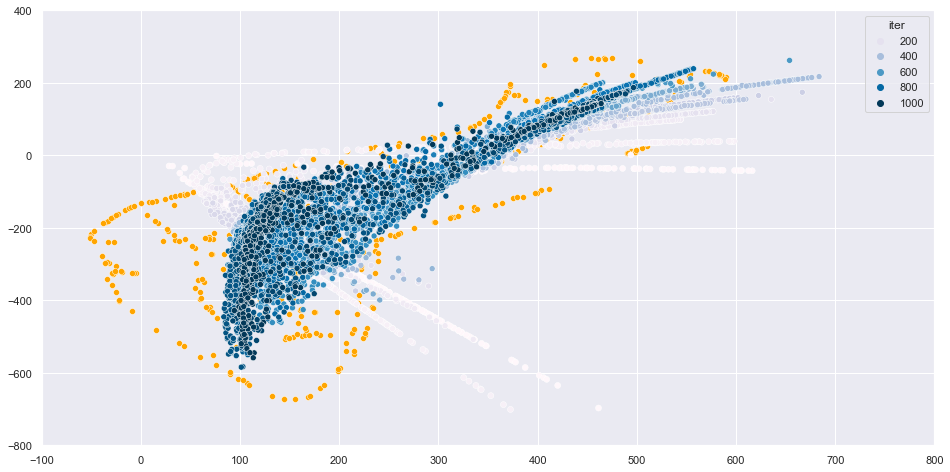

In [17]:
def plot_preds_converge(qs):
    dfs = pd.read_csv(f"preds_converge/{qs}_conv.csv")
    plt.figure(figsize=(16, 8))
    truth = pd.DataFrame(y_test_ae, columns=["x", "y", "z"])
    sns.scatterplot(x="x", y="y", data=truth, color="orange")
    ax = sns.scatterplot(x="x", y="y", data=dfs, hue="iter", palette="PuBu")
    ax.xaxis.label.set_visible(False)
    ax.yaxis.label.set_visible(False)
    plt.xlim(-100, 800)
    plt.ylim(-800, 400)
    

plot_preds_converge("random")

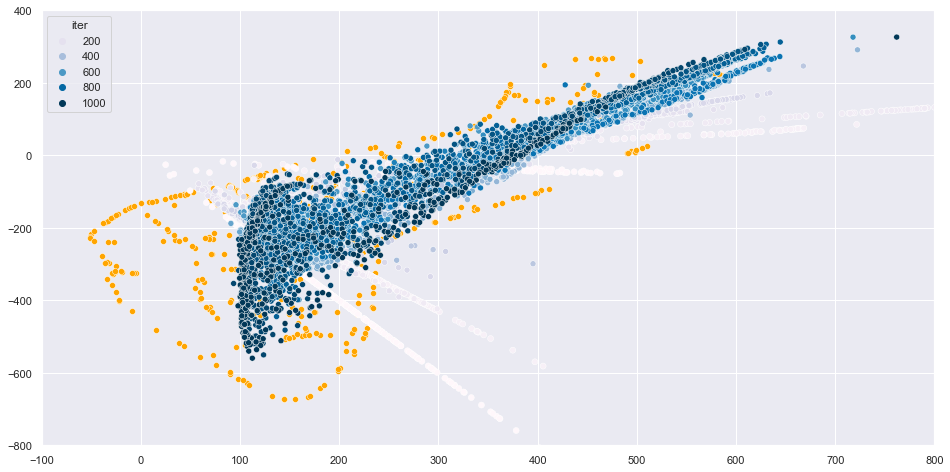

In [18]:
plot_preds_converge("margin")

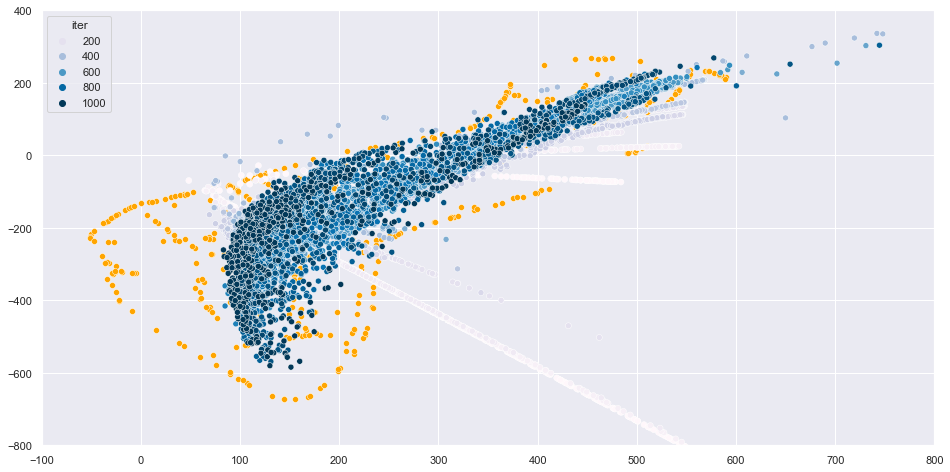

In [67]:
plot_preds_converge("lb2")

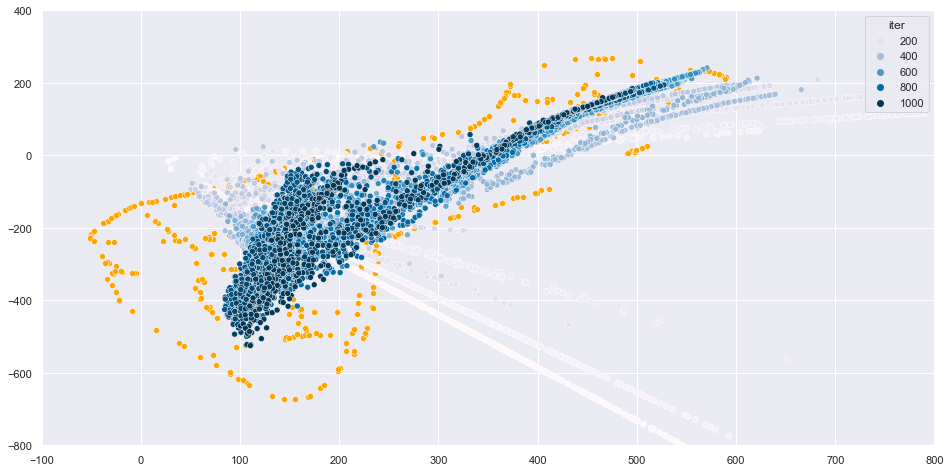

In [20]:
plot_preds_converge("uncertainty")

In [132]:
# dfs = pd.read_csv(f"preds_converge/random_conv.csv")
# df_dict = {}
# iter_list = list(dfs["iter"].unique())
# iter_max = max(dfs["iter"].unique())
# for _iter in iter_list:
#     df_dict[_iter] = dfs[dfs["iter"]==_iter].reset_index()

# for idx, _iter in enumerate(iter_list[:-1]):
#     df_next = df_dict[iter_list[idx + 1]]
#     for idx, row in df_dict[_iter].iterrows():
#         _row_next_iter = df_next.iloc[idx]
#         plt.plot([row["x"], _row_next_iter["x"]], [row["y"], _row_next_iter["y"]],
#                 color=(((iter_max - _iter)*100/iter_max)/255,((iter_max - _iter)*100/iter_max)/255,((iter_max - _iter)*100/iter_max)/255))
        
# plt.xlim(-100, 800)
# plt.ylim(-700, 400)

(-700.0, 400.0)

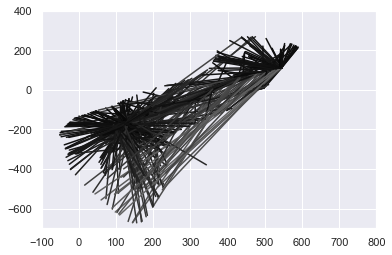

In [68]:
import math
import matplotlib.pylab as pl
#colors = pl.cm.jet(np.linspace(0,1,n))

dfs = pd.read_csv(f"preds_converge/lb2_conv.csv")
df_1k = dfs[dfs["iter"]==250].reset_index()
df_y = pd.DataFrame(y_test_ae_cnn, columns=["x_truth", "y_truth", "z_truth"])
df_1k["x_truth"] = df_y["x_truth"]
df_1k["y_truth"] = df_y["y_truth"]
df_1k["z_truth"] = df_y["z_truth"]
df_1k["dist"] = df_1k.apply(lambda row: math.sqrt((row["x"] - row["x_truth"])**2 + (row["y"] - row["y_truth"])**2), axis=1)
min_dist, max_dist = min(df_1k["dist"]), max(df_1k["dist"])

for idx, row in df_1k.iterrows():
    plt.plot([row["x"], row["x_truth"]], [row["y"], row["y_truth"]],
             color=((row["dist"]*100/max_dist)/255,(row["dist"]*100/max_dist)/255,(row["dist"]*100/max_dist)/255))
plt.xlim(-100, 800)
plt.ylim(-700, 400)

(-700.0, 400.0)

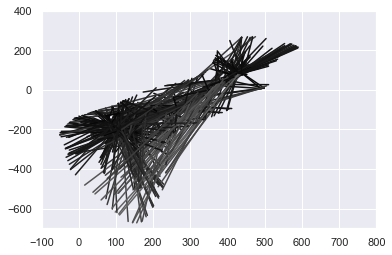

In [119]:
dfs = pd.read_csv(f"preds_converge/random_conv.csv")
df_1k = dfs[dfs["iter"]==250].reset_index()
df_y = pd.DataFrame(y_test_ae_cnn, columns=["x_truth", "y_truth", "z_truth"])
df_1k["x_truth"] = df_y["x_truth"]
df_1k["y_truth"] = df_y["y_truth"]
df_1k["z_truth"] = df_y["z_truth"]
df_1k["dist"] = df_1k.apply(lambda row: math.sqrt((row["x"] - row["x_truth"])**2 + (row["y"] - row["y_truth"])**2), axis=1)
min_dist, max_dist = min(df_1k["dist"]), max(df_1k["dist"])

for idx, row in df_1k.iterrows():
    plt.plot([row["x"], row["x_truth"]], [row["y"], row["y_truth"]],
            color=((row["dist"]*100/max_dist)/255,(row["dist"]*100/max_dist)/255,(row["dist"]*100/max_dist)/255))
plt.xlim(-100, 800)
plt.ylim(-700, 400)